# EXP-006 — Binary Classification Cases A1–A6
SeqBoostNet on each of the six pairwise binary cases defined in the paper.
For each case: filter → stratified split → StandardScaler+FFT+UMAP → LSTM+XGB+GB→AdaBoost.
Metrics: Accuracy, Precision, Recall, F1, F2, Kappa, MCC, ROC-AUC, Sensitivity, Specificity, Log Loss.

| Case | Classes |
|------|---------|
| A1 | Generalized vs Focal |
| A2 | Generalized vs Healthy |
| A3 | Focal vs Healthy |
| A4 | Focal vs Seizure Events |
| A5 | Generalized vs Seizure Events |
| A6 | Seizure Events vs Healthy |

In [1]:
import sys, os
sys.path.insert(0, str(__import__('pathlib').Path('..').resolve()))
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import keras
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping

from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, fbeta_score, cohen_kappa_score,
    matthews_corrcoef, roc_auc_score, log_loss,
    confusion_matrix, classification_report,
)
from umap import UMAP

from src.beed.data import load_raw
from src.beed.features import fft_features, scale
from src.beed.config import CLASS_LABELS, DATA_PROCESSED, FIGURES, RANDOM_STATE, CHANNEL_NAMES, N_UMAP_COMPONENTS

FIGURES.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
sns.set_theme(style='whitegrid')
print('Ready.')

Ready.


## 1. Case definitions and helpers

In [2]:
# cls_0 → binary label 0 (negative), cls_1 → binary label 1 (positive/seizure of interest)
CASES = {
    'A1': {'title': 'Generalized vs Focal',         'cls_0': 1, 'cls_1': 2},
    'A2': {'title': 'Generalized vs Healthy',        'cls_0': 0, 'cls_1': 2},
    'A3': {'title': 'Focal vs Healthy',              'cls_0': 0, 'cls_1': 1},
    'A4': {'title': 'Focal vs Seizure Events',       'cls_0': 3, 'cls_1': 1},
    'A5': {'title': 'Generalized vs Seizure Events', 'cls_0': 3, 'cls_1': 2},
    'A6': {'title': 'Seizure Events vs Healthy',     'cls_0': 0, 'cls_1': 3},
}

# Paper-reported test accuracy for comparison
PAPER = {
    'A1': 95.91, 'A2': 99.66, 'A3': 99.83,
    'A4': 91.16, 'A5': 94.01, 'A6': 99.66,
}

df_all = load_raw()
print('Raw data loaded:', df_all.shape)
for k, v in CASES.items():
    print(f"  {k}: {v['title']}  "
          f"(labels {v['cls_0']}={CLASS_LABELS[v['cls_0']]} vs "
          f"{v['cls_1']}={CLASS_LABELS[v['cls_1']]})")

Raw data loaded: (8000, 17)
  A1: Generalized vs Focal  (labels 1=Focal vs 2=Generalized)
  A2: Generalized vs Healthy  (labels 0=Healthy vs 2=Generalized)
  A3: Focal vs Healthy  (labels 0=Healthy vs 1=Focal)
  A4: Focal vs Seizure Events  (labels 3=Seizure Events vs 1=Focal)
  A5: Generalized vs Seizure Events  (labels 3=Seizure Events vs 2=Generalized)
  A6: Seizure Events vs Healthy  (labels 0=Healthy vs 3=Seizure Events)


In [3]:
def make_binary_split(df_full, cls_0, cls_1, test_size=0.2, val_size=0.1):
    """Filter to two classes, remap to 0/1, return stratified train/val/test."""
    df = df_full[df_full['y'].isin([cls_0, cls_1])].copy()
    df['y'] = df['y'].map({cls_0: 0, cls_1: 1})
    X, y = df.drop(columns=['y']), df['y']
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=RANDOM_STATE
    )
    val_rel = val_size / (1 - test_size)
    X_tr, X_va, y_tr, y_va = train_test_split(
        X_tr, y_tr, test_size=val_rel, stratify=y_tr, random_state=RANDOM_STATE
    )
    return X_tr, X_va, X_te, y_tr.values, y_va.values, y_te.values


def build_features_binary(X_tr_raw, X_va_raw, X_te_raw):
    """StandardScaler → FFT (16) + UMAP (3) = 19 features. Fit on train only."""
    X_tr_sc, scaler = scale(X_tr_raw, fit=True)
    X_va_sc, _      = scale(X_va_raw, scaler=scaler, fit=False)
    X_te_sc, _      = scale(X_te_raw, scaler=scaler, fit=False)

    fft_tr = fft_features(X_tr_sc)
    fft_va = fft_features(X_va_sc)
    fft_te = fft_features(X_te_sc)

    reducer = UMAP(n_components=N_UMAP_COMPONENTS, random_state=RANDOM_STATE)
    umap_tr = pd.DataFrame(
        reducer.fit_transform(X_tr_sc[CHANNEL_NAMES].values),
        columns=[f'umap_{i+1}' for i in range(N_UMAP_COMPONENTS)],
        index=X_tr_sc.index,
    )
    umap_va = pd.DataFrame(
        reducer.transform(X_va_sc[CHANNEL_NAMES].values),
        columns=[f'umap_{i+1}' for i in range(N_UMAP_COMPONENTS)],
        index=X_va_sc.index,
    )
    umap_te = pd.DataFrame(
        reducer.transform(X_te_sc[CHANNEL_NAMES].values),
        columns=[f'umap_{i+1}' for i in range(N_UMAP_COMPONENTS)],
        index=X_te_sc.index,
    )

    feat_tr = pd.concat([fft_tr, umap_tr], axis=1).values.astype(np.float32)
    feat_va = pd.concat([fft_va, umap_va], axis=1).values.astype(np.float32)
    feat_te = pd.concat([fft_te, umap_te], axis=1).values.astype(np.float32)
    return feat_tr, feat_va, feat_te


def build_lstm_bin(n_features=19):
    m = Sequential([
        LSTM(128, activation='relu', input_shape=(n_features, 1)),
        Dropout(0.5),
        Dense(2, activation='softmax'),
    ])
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m


def build_xgb_bin():
    return XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1,
    )


def build_gb_bin():
    return GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=3, random_state=RANDOM_STATE,
    )


def compute_metrics(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return {
        'Accuracy':    round(accuracy_score(y_true, y_pred) * 100, 2),
        'Precision':   round(precision_score(y_true, y_pred, zero_division=0) * 100, 2),
        'Recall':      round(recall_score(y_true, y_pred, zero_division=0) * 100, 2),
        'F1':          round(f1_score(y_true, y_pred, zero_division=0) * 100, 2),
        'F2':          round(fbeta_score(y_true, y_pred, beta=2, zero_division=0) * 100, 2),
        'Kappa':       round(cohen_kappa_score(y_true, y_pred) * 100, 2),
        'MCC':         round(matthews_corrcoef(y_true, y_pred) * 100, 2),
        'ROC-AUC':     round(roc_auc_score(y_true, y_prob[:, 1]) * 100, 2),
        'Sensitivity': round(sensitivity * 100, 2),
        'Specificity': round(specificity * 100, 2),
        'LogLoss':     round(log_loss(y_true, y_prob), 4),
    }


print('Helpers defined.')

Helpers defined.


## 2. Run all six cases
For each case: filter → split → FFT+UMAP features → 3-fold OOF stacking → AdaBoost → metrics.

In [4]:
N_FOLDS = 3
all_results   = {}   # case_id → metrics dict
all_cms       = {}   # case_id → confusion matrix
all_preds     = {}   # case_id → (y_test, preds, probs)

for case_id, cfg in CASES.items():
    print(f'\n{"="*60}')
    print(f'{case_id}: {cfg["title"]}')
    print(f'{"="*60}')

    # --- split ---
    X_tr, X_va, X_te, y_tr, y_va, y_te = make_binary_split(
        df_all, cfg['cls_0'], cfg['cls_1']
    )
    print(f'  Train {X_tr.shape[0]}  Val {X_va.shape[0]}  Test {X_te.shape[0]}')

    # --- feature pipeline ---
    print('  Building FFT+UMAP features...')
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        feat_tr, feat_va, feat_te = build_features_binary(X_tr, X_va, X_te)
    print(f'  Features: {feat_tr.shape}')

    feat_tr3 = feat_tr.reshape(-1, feat_tr.shape[1], 1)
    feat_va3 = feat_va.reshape(-1, feat_va.shape[1], 1)
    feat_te3 = feat_te.reshape(-1, feat_te.shape[1], 1)

    # --- OOF stacking ---
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    meta_tr = np.zeros((len(feat_tr), 6), dtype=np.float32)  # 2 probs × 3 models

    for fold_idx, (fi_tr, fi_va) in enumerate(skf.split(feat_tr, y_tr)):
        Xf_tr2, Xf_va2 = feat_tr[fi_tr],  feat_tr[fi_va]
        Xf_tr3, Xf_va3 = feat_tr3[fi_tr], feat_tr3[fi_va]
        yf_tr,  yf_va  = y_tr[fi_tr],     y_tr[fi_va]

        keras.utils.set_random_seed(RANDOM_STATE + fold_idx)
        lstm = build_lstm_bin()
        lstm.fit(Xf_tr3, yf_tr, validation_data=(Xf_va3, yf_va),
                 epochs=10, batch_size=32, verbose=0)
        meta_tr[fi_va, :2] = lstm.predict(Xf_va3, verbose=0)
        del lstm; keras.backend.clear_session()

        xgb = build_xgb_bin()
        xgb.fit(Xf_tr2, yf_tr, eval_set=[(Xf_va2, yf_va)], verbose=False)
        meta_tr[fi_va, 2:4] = xgb.predict_proba(Xf_va2)

        gb = build_gb_bin()
        gb.fit(Xf_tr2, yf_tr)
        meta_tr[fi_va, 4:] = gb.predict_proba(Xf_va2)

    print(f'  OOF complete. meta_tr shape: {meta_tr.shape}')

    # --- AdaBoost meta-model ---
    ada = AdaBoostClassifier(n_estimators=50, learning_rate=1.0, random_state=RANDOM_STATE)
    ada.fit(meta_tr, y_tr)

    # --- retrain base models on full train ---
    keras.utils.set_random_seed(RANDOM_STATE)
    final_lstm = build_lstm_bin()
    final_lstm.fit(feat_tr3, y_tr, validation_data=(feat_va3, y_va),
                   epochs=30, batch_size=32,
                   callbacks=[EarlyStopping(patience=8, restore_best_weights=True, verbose=0)],
                   verbose=0)

    final_xgb = build_xgb_bin()
    final_xgb.fit(feat_tr, y_tr, eval_set=[(feat_va, y_va)], verbose=False)

    final_gb = build_gb_bin()
    final_gb.fit(feat_tr, y_tr)

    # --- inference ---
    def predict_case(X2, X3):
        p_lstm = final_lstm.predict(X3, verbose=0)
        p_xgb  = final_xgb.predict_proba(X2)
        p_gb   = final_gb.predict_proba(X2)
        meta   = np.hstack([p_lstm, p_xgb, p_gb])
        return ada.predict(meta), ada.predict_proba(meta)

    preds_te, probs_te = predict_case(feat_te, feat_te3)

    metrics = compute_metrics(y_te, preds_te, probs_te)
    all_results[case_id] = metrics
    all_cms[case_id]     = confusion_matrix(y_te, preds_te)
    all_preds[case_id]   = (y_te, preds_te, probs_te)

    del final_lstm; keras.backend.clear_session()

    print(f'  Accuracy={metrics["Accuracy"]:.2f}%  '
          f'F1={metrics["F1"]:.2f}%  '
          f'ROC-AUC={metrics["ROC-AUC"]:.2f}%')

print('\nAll cases complete.')


A1: Generalized vs Focal
  Train 2800  Val 400  Test 800
  Building FFT+UMAP features...


  Features: (2800, 19)


C:\dev\BEED\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


C:\dev\BEED\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


C:\dev\BEED\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

C:\dev\BEED\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


C:\dev\BEED\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  OOF complete. meta_tr shape: (2800, 6)


C:\dev\BEED\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Accuracy=99.75%  F1=99.75%  ROC-AUC=99.99%

All cases complete.


## 3. Results table

In [5]:
rows = []
for case_id, metrics in all_results.items():
    rows.append({'Case': case_id, 'Title': CASES[case_id]['title'], **metrics})

results_df = pd.DataFrame(rows).set_index('Case')
results_df.to_csv(DATA_PROCESSED / 'exp006_binary_results.csv')
print('=== EXP-006 Results (test set) ===')
results_df

=== EXP-006 Results (test set) ===


,Title,Accuracy,Precision,Recall,F1,F2,Kappa,MCC,ROC-AUC,Sensitivity,Specificity,LogLoss
Case,,,,,,,,,,,,
A1,Generalized vs Focal,93.62,92.05,95.50,93.74,94.79,87.25,87.31,97.25,95.50,91.75,0.4131
A2,Generalized vs Healthy,99.62,99.26,100.00,99.63,99.85,99.25,99.25,99.62,100.00,99.25,0.3443
A3,Focal vs Healthy,99.88,99.75,100.00,99.88,99.95,99.75,99.75,100.00,100.00,99.75,0.3086
A4,Focal vs Seizure Events,93.25,92.82,93.75,93.28,93.56,86.50,86.50,97.23,93.75,92.75,0.4269
A5,Generalized vs Seizure Events,87.25,84.02,92.00,87.83,90.28,74.50,74.84,95.13,92.00,82.50,0.4654
A6,Seizure Events vs Healthy,99.75,99.50,100.00,99.75,99.90,99.50,99.50,99.99,100.00,99.50,0.3117


## 4. Comparison with paper

In [6]:
cmp_rows = []
for case_id in CASES:
    ours  = all_results[case_id]['Accuracy']
    paper = PAPER[case_id]
    cmp_rows.append({
        'Case':  case_id,
        'Title': CASES[case_id]['title'],
        'Ours (%)': ours,
        'Paper (%)': paper,
        'Δ (pp)': round(ours - paper, 2),
    })

cmp_df = pd.DataFrame(cmp_rows)
cmp_df.loc[len(cmp_df)] = {
    'Case': 'Avg',
    'Title': '',
    'Ours (%)':  round(cmp_df['Ours (%)'].mean(), 2),
    'Paper (%)': round(cmp_df['Paper (%)'].mean(), 2),
    'Δ (pp)':    round(cmp_df['Δ (pp)'].mean(), 2),
}
print(cmp_df.to_string(index=False))

Case                         Title  Ours (%)  Paper (%)  Δ (pp)
  A1          Generalized vs Focal     93.62      95.91   -2.29
  A2        Generalized vs Healthy     99.62      99.66   -0.04
  A3              Focal vs Healthy     99.88      99.83    0.05
  A4       Focal vs Seizure Events     93.25      91.16    2.09
  A5 Generalized vs Seizure Events     87.25      94.01   -6.76
  A6     Seizure Events vs Healthy     99.75      99.66    0.09
 Avg                                   95.56      96.70   -1.14


## 5. Accuracy comparison chart

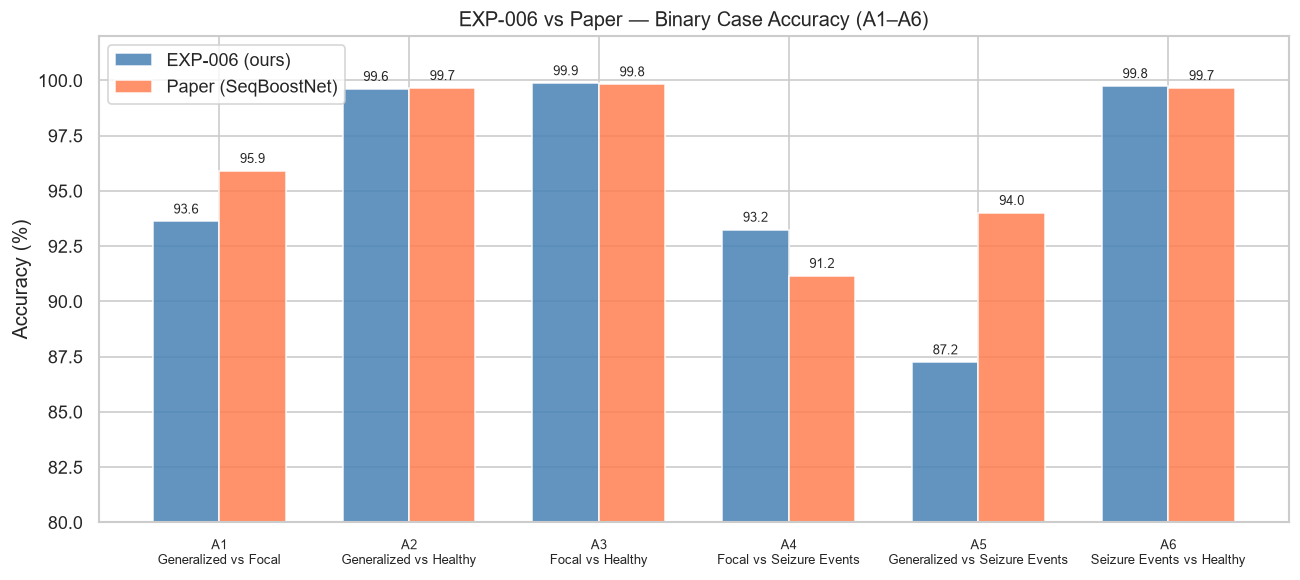

In [7]:
cases_list = list(CASES.keys())
ours_acc   = [all_results[c]['Accuracy'] for c in cases_list]
paper_acc  = [PAPER[c] for c in cases_list]

x = np.arange(len(cases_list))
w = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars_ours  = ax.bar(x - w/2, ours_acc,  w, label='EXP-006 (ours)', color='steelblue', alpha=0.85)
bars_paper = ax.bar(x + w/2, paper_acc, w, label='Paper (SeqBoostNet)', color='coral',     alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([f'{c}\n{CASES[c]["title"]}' for c in cases_list], fontsize=8)
ax.set_ylim(80, 102)
ax.set_ylabel('Accuracy (%)')
ax.set_title('EXP-006 vs Paper — Binary Case Accuracy (A1–A6)')
ax.legend()
ax.bar_label(bars_ours,  fmt='%.1f', padding=3, fontsize=8)
ax.bar_label(bars_paper, fmt='%.1f', padding=3, fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES / '21_binary_accuracy_comparison.png', bbox_inches='tight')
plt.show()

## 6. Confusion matrix grid

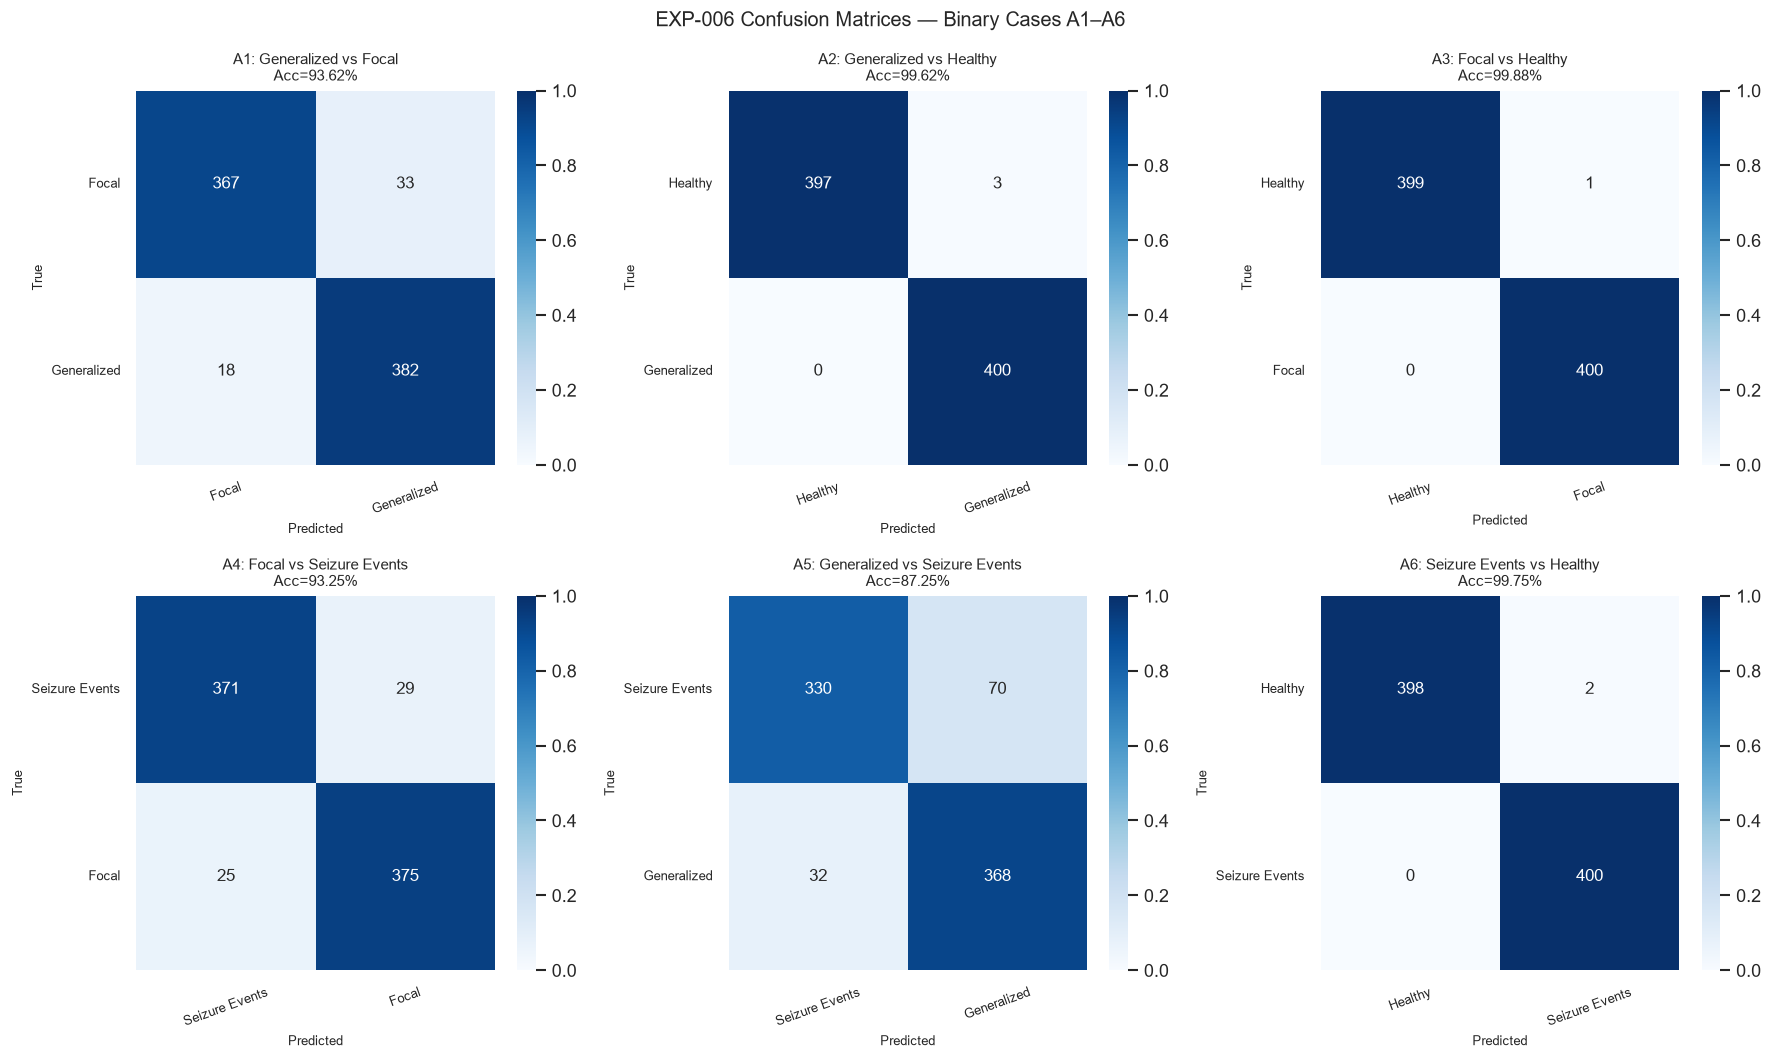

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, (case_id, cfg) in zip(axes.ravel(), CASES.items()):
    cm = all_cms[case_id]
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    labels = [CLASS_LABELS[cfg['cls_0']], CLASS_LABELS[cfg['cls_1']]]
    sns.heatmap(
        cm_norm, annot=cm, fmt='d', ax=ax,
        xticklabels=labels, yticklabels=labels,
        cmap='Blues', vmin=0, vmax=1, annot_kws={'size': 10},
    )
    acc = all_results[case_id]['Accuracy']
    ax.set_title(f'{case_id}: {cfg["title"]}\nAcc={acc:.2f}%', fontsize=9)
    ax.set_xlabel('Predicted', fontsize=8)
    ax.set_ylabel('True', fontsize=8)
    ax.tick_params(axis='x', rotation=20, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)

fig.suptitle('EXP-006 Confusion Matrices — Binary Cases A1–A6', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / '22_binary_confusion_grid.png', bbox_inches='tight')
plt.show()

## 7. Per-case metric summary

In [9]:
metrics_cols = ['Accuracy','Precision','Recall','F1','F2','Kappa','MCC','ROC-AUC','Sensitivity','Specificity','LogLoss']
print('Full metric table (test set):')
results_df[metrics_cols]

Full metric table (test set):


,Accuracy,Precision,Recall,F1,F2,Kappa,MCC,ROC-AUC,Sensitivity,Specificity,LogLoss
Case,,,,,,,,,,,
A1,93.62,92.05,95.50,93.74,94.79,87.25,87.31,97.25,95.50,91.75,0.4131
A2,99.62,99.26,100.00,99.63,99.85,99.25,99.25,99.62,100.00,99.25,0.3443
A3,99.88,99.75,100.00,99.88,99.95,99.75,99.75,100.00,100.00,99.75,0.3086
A4,93.25,92.82,93.75,93.28,93.56,86.50,86.50,97.23,93.75,92.75,0.4269
A5,87.25,84.02,92.00,87.83,90.28,74.50,74.84,95.13,92.00,82.50,0.4654
A6,99.75,99.50,100.00,99.75,99.90,99.50,99.50,99.99,100.00,99.50,0.3117


## 8. Summary

In [10]:
avg_ours  = cmp_df[cmp_df['Case'] == 'Avg']['Ours (%)'].values[0]
avg_paper = cmp_df[cmp_df['Case'] == 'Avg']['Paper (%)'].values[0]
avg_delta = cmp_df[cmp_df['Case'] == 'Avg']['Δ (pp)'].values[0]

print('=== EXP-006 Summary ===')
print('Architecture : SeqBoostNet (LSTM+XGB+GB→AdaBoost), same as EXP-005')
print('Feature set  : per-case StandardScaler+FFT+UMAP (19 features, refit per case)')
print('Stacking     : 3-fold OOF (10 CV epochs LSTM / 30 final epochs)')
print()
print(f'Our avg accuracy  : {avg_ours:.2f}%')
print(f'Paper avg accuracy: {avg_paper:.2f}%')
print(f'Δ                 : {avg_delta:+.2f} pp')
print()
best = max(all_results, key=lambda c: all_results[c]['Accuracy'])
worst = min(all_results, key=lambda c: all_results[c]['Accuracy'])
print(f'Best case  : {best} ({CASES[best]["title"]}) — {all_results[best]["Accuracy"]:.2f}%')
print(f'Worst case : {worst} ({CASES[worst]["title"]}) — {all_results[worst]["Accuracy"]:.2f}%')
print()
print('Paper-reported hardest case: A4 (Focal vs Seizure Events, 91.16%)')

=== EXP-006 Summary ===
Architecture : SeqBoostNet (LSTM+XGB+GB→AdaBoost), same as EXP-005
Feature set  : per-case StandardScaler+FFT+UMAP (19 features, refit per case)
Stacking     : 3-fold OOF (10 CV epochs LSTM / 30 final epochs)

Our avg accuracy  : 95.56%
Paper avg accuracy: 96.70%
Δ                 : -1.14 pp

Best case  : A3 (Focal vs Healthy) — 99.88%
Worst case : A5 (Generalized vs Seizure Events) — 87.25%

Paper-reported hardest case: A4 (Focal vs Seizure Events, 91.16%)
